# AE 498 PDR — 2024 PDC25 Kinetic Impactor Mission Design

**Pipeline:**
1. Run GRSS once → daily asteroid states from epoch to impact
2. SPICE → daily Earth states
3. Lambert sweep → porkchop plot (C3 vs departure/arrival)
4. Pick best dates → compute v_rel, ΔV to asteroid
5. B-plane before/after deflection

## Cell 1 — Imports & Constants

In [5]:
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import spiceypy as spice
from astropy.time import Time
from grss import libgrss, utils, prop
import grss

# ── Constants ────────────────────────────────────────────────
AU_KM   = 149597870.7          # km per au
AU_M    = 1.49597870700e11     # metres per AU
DAY_S   = 86400.0              # seconds per day
R_e_km  = 6371.0               # Earth radius km
R_earth = R_e_km / AU_KM       # Earth radius AU
MU_SUN  = 1.32712440018e11 / AU_KM**3 * DAY_S**2   # AU³/day²
MU_EARTH_KMS = 3.986004418e5   # km³/s²
J2000_MJD = 51544.5            # MJD of J2000 epoch


MASS_KG   = 3.93e9
RADIUS_AU = 0.075 / AU_KM

def et_to_mjd(et):  return J2000_MJD + et / DAY_S
def mjd_to_et(mjd): return (mjd - J2000_MJD) * DAY_S

print('Imports OK')
print(f'MU_SUN = {MU_SUN:.6e} au³/day²')

Imports OK
MU_SUN = 2.959122e-04 au³/day²


## Cell 2 — Load SPICE Kernels & OD Solution

In [6]:
# Load SPICE kernels (same as your working code)
spice.furnsh('naif0012.tls')
spice.furnsh('2024_PDC25a-s3-merged-DE441.bsp')
print('SPICE kernels loaded')

# Load OD solution
with open('./data/sol.json', 'r') as f:
    sol = json.load(f)
print('OD solution loaded')
print(f"  Epoch MJD = {sol['t']:.4f}")
for k,v in sol.items():
    print(f'  {k:6s} = {v:.10e}')

SPICE kernels loaded
OD solution loaded
  Epoch MJD = 61002.0000
  t      = 6.1002000000e+04
  e      = 3.9039777299e-01
  q      = 1.0059188243e+00
  tp     = 6.1214636873e+04
  om     = 3.7422838533e+00
  w      = 6.2821620106e+00
  i      = 1.8651518237e-01
  a2     = 1.0043516623e-13


## Cell 3 — Run GRSS Once: Asteroid Daily States from Epoch to Impact

This is the key cell. We propagate the nominal asteroid once and save every day's state.
Then we can interpolate to get asteroid position at **any** arrival date — no need to re-run GRSS for each Lambert call.

In [8]:
from grss import prop, utils
import json
import numpy as np
import spiceypy as spice
from astropy.time import Time

# ── Constants ─────────────────────────────────────────────────
AU_KM     = 149597870.7
DAY_S     = 86400.0
J2000_MJD = 51544.5
MU_SUN    = 1.32712440018e11 / AU_KM**3 * DAY_S**2

def et_to_mjd(et):  return J2000_MJD + et / DAY_S
def mjd_to_et(mjd): return (mjd - J2000_MJD) * DAY_S

# ── Load OD solution ──────────────────────────────────────────
with open('./data/sol.json', 'r') as f:
    init_sol = json.load(f)

nongrav_info = {
    'a1'    : 0.0,
    'a2'    : init_sol['a2'],
    'a3'    : 0.0,
    'alpha' : 1.0,
    'k'     : 0.0,
    'm'     : 2.0,
    'n'     : 0.0,
    'r0_au' : 1.0,
    'radius': 75.0,
}

mjd_end   = Time('2041-04-25', scale='tdb', format='iso').tdb.mjd

from grss import libgrss

# ── Use GRSS's own cometary→cartesian conversion ─────────────
# cometaryState = [e, q, tp, om, w, i]  (angles in radians, tp in MJD)
cometary_state = [
    init_sol['e'],
    init_sol['q'],
    init_sol['tp'],
    init_sol['om'],
    init_sol['w'],
    init_sol['i'],
]
cart = libgrss.cometary_to_cartesian(init_sol['t'], cometary_state)
r0 = cart[:3]
v0 = cart[3:]

print(f'r0 = {r0}')
print(f'v0 = {v0}')

# ── Build NongravParameters ───────────────────────────────────
ng = prop.NongravParameters()
ng.a1    = nongrav_info['a1']
ng.a2    = nongrav_info['a2']
ng.a3    = nongrav_info['a3']
ng.alpha = nongrav_info['alpha']
ng.k     = nongrav_info['k']
ng.m     = nongrav_info['m']
ng.n     = nongrav_info['n']
ng.r0_au = nongrav_info['r0_au']

# ── IntegBody + PropSimulation (matching working code exactly) ─
n_days   = int(mjd_end - init_sol['t']) + 1
t_eval   = [init_sol['t'] + i for i in range(n_days)]
t_eval_mjd = np.array(t_eval)
mjd_start  = t_eval_mjd[0]

body = prop.IntegBody(
    '2024PDC25', init_sol['t'], 0.0, 0.0,
    list(r0), list(v0), ng
)

sim = prop.PropSimulation(
    '2024PDC25_prop', init_sol['t'], 440, utils.default_kernel_path
)
sim.set_integration_parameters(mjd_end, t_eval, False, False, False)
sim.add_integ_body(body)

print(f'Running GRSS daily propagation ({n_days} days)...')
sim.integrate()
print('Done.')

ast_states = np.array(sim.xIntegEval)
print(f'Stored {ast_states.shape[0]} daily states')

r0 = [0.44206006342998627, 1.8910912676327196, -0.24724375617573235]
v0 = [-0.010938519551098385, -0.0015716339621881167, -0.0009220449094127083]
Running GRSS daily propagation (5633 days)...
Done.
Stored 5633 daily states


## Cell 4 — Lambert Solver (Curtis Algorithm 5.2)

In [9]:
def stumpff_S(z):
    if   z >  0: return (np.sqrt(z) - np.sin(np.sqrt(z))) / z**1.5
    elif z <  0: return (np.sinh(np.sqrt(-z)) - np.sqrt(-z)) / (-z)**1.5
    else:        return 1.0/6.0

def stumpff_C(z):
    if   z >  0: return (1 - np.cos(np.sqrt(z))) / z
    elif z <  0: return (np.cosh(np.sqrt(-z)) - 1) / (-z)
    else:        return 0.5

def lambert(R1, R2, t, string='pro', mu=MU_SUN):
    """
    Curtis Algorithm 5.2 Lambert solver.
    R1, R2: position vectors [AU]
    t     : time of flight [days]
    Returns V1, V2 [AU/day]
    """
    R1 = np.array(R1, dtype=float)
    R2 = np.array(R2, dtype=float)
    r1 = np.linalg.norm(R1)
    r2 = np.linalg.norm(R2)
    c12 = np.cross(R1, R2)
    theta = np.arccos(np.clip(np.dot(R1, R2) / (r1 * r2), -1, 1))
    if string == 'pro':
        if c12[2] < 0: theta = 2*np.pi - theta
    elif string == 'retro':
        if c12[2] >= 0: theta = 2*np.pi - theta

    A = np.sin(theta) * np.sqrt(r1*r2 / (1 - np.cos(theta)))

    def y(z):
        return r1 + r2 + A*(z*stumpff_S(z) - 1) / np.sqrt(stumpff_C(z))

    def F(z, dt):
        return (y(z)/stumpff_C(z))**1.5 * stumpff_S(z) + A*np.sqrt(y(z)) - np.sqrt(mu)*dt

    def dFdz(z):
        if z == 0:
            return (np.sqrt(2)/40 * y(0)**1.5 +
                    A/8 * (np.sqrt(y(0)) + A*np.sqrt(1/(2*y(0)))))
        else:
            return ((y(z)/stumpff_C(z))**1.5 *
                    (1/(2*z) * (stumpff_C(z) - 3*stumpff_S(z)/(2*stumpff_C(z))) +
                     3*stumpff_S(z)**2/(4*stumpff_C(z))) +
                    A/8 * (3*(stumpff_S(z)/stumpff_C(z))*np.sqrt(y(z)) +
                           A*np.sqrt(stumpff_C(z)/y(z))))

    z = -100.0
    while F(z, t) < 0 if y(z) > 0 else True:
        z += 0.1

    tol = 1e-8; nmax = 5000; ratio = 1.0; n = 0
    while abs(ratio) > tol and n <= nmax:
        n += 1
        ratio = F(z, t) / dFdz(z)
        z -= ratio

    f    = 1 - y(z)/r1
    g    = A * np.sqrt(y(z)/mu)
    gdot = 1 - y(z)/r2
    V1 = (R2 - f*R1) / g
    V2 = (gdot*R2 - R1) / g
    return V1, V2

print('Lambert solver defined')

Lambert solver defined


## Cell 5 — Helper: Interpolate Asteroid & Earth States at Any MJD

In [10]:
# SPICE query constants — add these to Cell 2
FRAME    = 'ECLIPJ2000'
ABCORR   = 'NONE'
OBSERVER = 'SUN'

def asteroid_state_at(mjd):
    et = mjd_to_et(mjd)
    state, _ = spice.spkezr('-937020', et, 'ECLIPJ2000', 'NONE', 'SUN')
    r = np.array(state[:3]) / AU_KM
    v = np.array(state[3:]) / AU_KM * DAY_S
    return r, v

def earth_state_at(mjd):
    """
    Earth heliocentric state from SPICE at given MJD.
    Returns r [AU], v [AU/day]
    """
    et = mjd_to_et(mjd)
    state, _ = spice.spkezr('EARTH', et, FRAME, ABCORR, OBSERVER)
    r = np.array(state[:3]) / AU_KM
    v = np.array(state[3:]) / AU_KM * DAY_S
    return r, v



## Cell 6 — Porkchop Plot: Sweep Departure × Arrival Dates

In [ ]:
# ── Sweep parameters ─────────────────────────────────────────
# Departure window: 2037-01-01 to 2040-01-01
# Arrival window  : departure + 30 days to departure + 600 days
# (asteroid impact is April 24 2041 — intercept must be before that)

mjd_impact = et_to_mjd(spice.str2et('2041-04-24 15:24:50'))
print(f'Impact MJD = {mjd_impact:.4f}')

depart_start = et_to_mjd(spice.str2et('2030-01-01 00:00:00'))
depart_end   = et_to_mjd(spice.str2et('2035-06-01 00:00:00'))
depart_step  = 5   # days  (5-day grid for speed)

tof_min = 60    # days
tof_max = 700   # days
tof_step = 5    # days

depart_dates = np.arange(depart_start, depart_end,  depart_step)
tof_values   = np.arange(tof_min,     tof_max+1,    tof_step)

print(f'Departure dates: {len(depart_dates)} points  ({depart_step}-day step)')
print(f'TOF values     : {len(tof_values)} points  ({tof_step}-day step)')
print(f'Total Lambert calls: {len(depart_dates)*len(tof_values):,}')

# ── Allocate result grids ─────────────────────────────────────
C3_grid      = np.full((len(tof_values), len(depart_dates)), np.nan)
vrel_grid    = np.full((len(tof_values), len(depart_dates)), np.nan)
dv_tot_grid  = np.full((len(tof_values), len(depart_dates)), np.nan)

# ── Sweep ─────────────────────────────────────────────────────
print('\nRunning porkchop sweep...')
for j, t_dep in enumerate(depart_dates):
    r_earth_dep, v_earth_dep = earth_state_at(t_dep)

    for i, tof in enumerate(tof_values):
        t_arr = t_dep + tof

        # Must arrive before impact
        if t_arr >= mjd_impact - 30:
            continue
        # Must be within our GRSS data range
        if t_arr > t_eval_mjd[-1] or t_arr < t_eval_mjd[0]:
            continue

        r_ast_arr, v_ast_arr = asteroid_state_at(t_arr)

        try:
            V1_sc, V2_sc = lambert(r_earth_dep, r_ast_arr, tof)
        except Exception:
            continue

        # C3 = launch energy [km²/s²]
        dv_launch = V1_sc - v_earth_dep
        dv_launch_kms = np.linalg.norm(dv_launch) * AU_KM / DAY_S
        C3 = dv_launch_kms ** 2

        # v_rel at asteroid [km/s]
        dv_impact = V2_sc - v_ast_arr
        v_rel_kms = np.linalg.norm(dv_impact) * AU_KM / DAY_S

        # Total mission ΔV
        dv_total = dv_launch_kms + v_rel_kms

        C3_grid[i, j]     = C3
        vrel_grid[i, j]   = v_rel_kms
        dv_tot_grid[i, j] = dv_total
        
print('Sweep complete.')
valid = np.isfinite(C3_grid)
print(f'Valid solutions: {valid.sum():,} / {C3_grid.size:,}')
if valid.sum() > 0:
    print(f'C3 range : {np.nanmin(C3_grid):.2f} – {np.nanmax(C3_grid[C3_grid < 200]):.2f} km²/s²')
    print(f'v_rel range: {np.nanmin(vrel_grid):.2f} – {np.nanmax(vrel_grid[vrel_grid < 50]):.2f} km/s')
# ── Save porkchop data to file ────────────────────────────────
porkchop_data = {
    'depart_dates' : depart_dates.tolist(),
    'tof_values'   : tof_values.tolist(),
    'C3_grid'      : C3_grid.tolist(),
    'vrel_grid'    : vrel_grid.tolist(),
    'dv_tot_grid'  : dv_tot_grid.tolist(),
    'mjd_impact'   : mjd_impact,
}

with open('./data/porkchop_2.json', 'w') as f:
    json.dump(porkchop_data, f)

print(f'Saved porkchop data to ./data/porkchop_2.json')

Impact MJD = 66633.6430
Departure dates: 396 points  (5-day step)
TOF values     : 129 points  (5-day step)
Total Lambert calls: 51,084

Running porkchop sweep...
Sweep complete.
Valid solutions: 51,084 / 51,084
C3 range : 12.02 – 199.93 km²/s²
v_rel range: 1.03 – 49.99 km/s
Saved porkchop data to ./data/porkchop_2.json


Loaded porkchop: (129, 396) grid
b_coll = 1.7059 R⊕
── Asteroid ─────────────────────────────────────
  Radius         : 75.0 m
  Density        : 1900 kg/m³
  Mass           : 3.3576e+09 kg
── Nuclear device ───────────────────────────────
  Yield          : 1.0 MT  =  4.184e+15 J
  Standoff height: 1000.0 m  (13.33 × R_ast)
  Burst radius   : 1075.0 m from centre
── Coupling ─────────────────────────────────────
  f_geo          : 0.0012  (0.12% of fluence intercepted)
  η_ablation     : 0.1
  v_ej           : 2000 m/s
  E deposited    : 5.098e+11 J
── Result ───────────────────────────────────────
  ΔV on asteroid : 0.1518 m/s  (0.000152 km/s)
─────────────────────────────────────────────────
  v_esc          : 7.73 cm/s
  ΔV / v_esc     : 2.0×  ← intermediate: fragmentation risk

Total Lambert-valid points : 51,084
After dv_total < 15.0 km/s filter : 3,088  (6.0% retained)
Running nuclear standoff b-plane sweep...
Parallel propagation took 00 minute(s) and 0.356830 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.013340 seconds
Parallel propagation took 00 minute(s) and 0.115016 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.008687 seconds
Parallel propagation took 00 minute(s) and 0.129279 seconds


...

  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.004899 seconds
Parallel propagation took 00 minute(s) and 0.087919 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.005213 seconds

Sweep complete. 3088 points evaluated.
Successful deflections: 3088 / 3088  (100.0%)
Saved ./data/bplane_sweep_nuclear.json


/var/folders/1_/l5p8yy_x2d5flcqc9w5tbg3m0000gn/T/ipykernel_18480/1009091171.py:261: UserWarning: The following kwargs were not used by contour: 'label'
  ax2.contour(X, Y_mesh, dv_total_grid,


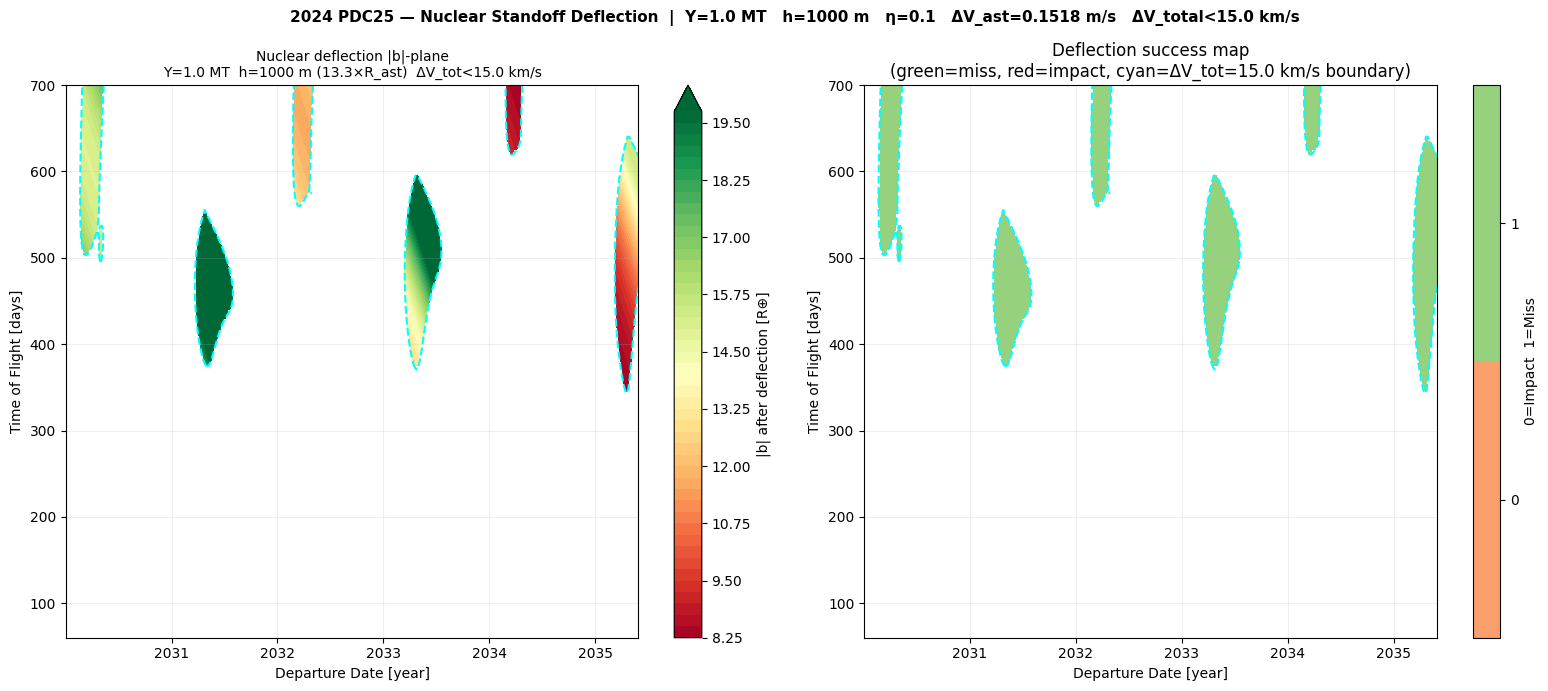

Saved bplane_porkchop_nuclear.png


In [16]:
# ── Load porkchop data ────────────────────────────────────────
with open('./data/porkchop_2.json', 'r') as f:
    pc = json.load(f)

depart_dates = np.array(pc['depart_dates'])
tof_values   = np.array(pc['tof_values'])
C3_grid      = np.array(pc['C3_grid'])
vrel_grid    = np.array(pc['vrel_grid'])
mjd_impact   = pc['mjd_impact']
dv_total_grid    = np.array(pc['dv_tot_grid'])


print(f'Loaded porkchop: {C3_grid.shape} grid')

# ── Constants ─────────────────────────────────────────────────
AU_KM        = 149597870.7
DAY_S        = 86400.0
R_e_km       = 6371.0
MU_EARTH_KMS = 3.986004418e5

# ── Nominal b-plane ───────────────────────────────────────────
with open('./data/nominal_bplane.json') as f:
    bp_data = json.load(f)
nom        = bp_data['nominal']
U0_kms     = nom['vInf'] * AU_KM / DAY_S
b_coll_km  = R_e_km * np.sqrt(1 + 2*MU_EARTH_KMS / (R_e_km * U0_kms**2))
b_coll_Re  = b_coll_km / R_e_km
print(f'b_coll = {b_coll_Re:.4f} R⊕')

# ── Asteroid physical parameters ──────────────────────────────
rho_ast  = 1900.0        # kg/m³
R_ast_m  = 75.0          # asteroid radius [m]
m_ast    = (4/3) * np.pi * R_ast_m**3 * rho_ast

# ── Nuclear standoff parameters  ← ALL VARIABLES ─────────────
Y_MT         = 1.0       # yield [megatons]
h_standoff   = 1000.0     # standoff height above surface [m]
eta_ablation = 0.1       # X-ray → momentum coupling efficiency
v_ej_ms      = 2000.0    # ablation ejecta velocity [m/s]

# ── Derived nuclear quantities ────────────────────────────────
J_per_MT     = 4.184e15
Y_J          = Y_MT * J_per_MT
r_burst_m    = R_ast_m + h_standoff

sin_theta    = R_ast_m / r_burst_m
cos_theta    = np.sqrt(1.0 - sin_theta**2)
f_geo        = 0.5 * (1.0 - cos_theta)

E_dep        = eta_ablation * f_geo * Y_J
dv_ast_ms    = (2.0 * E_dep) / (m_ast * v_ej_ms)
dv_ast_kms   = dv_ast_ms / 1000.0
dv_ast_AUday = dv_ast_kms / (AU_KM / DAY_S)

print(f'── Asteroid ─────────────────────────────────────')
print(f'  Radius         : {R_ast_m:.1f} m')
print(f'  Density        : {rho_ast:.0f} kg/m³')
print(f'  Mass           : {m_ast:.4e} kg')
print(f'── Nuclear device ───────────────────────────────')
print(f'  Yield          : {Y_MT} MT  =  {Y_J:.3e} J')
print(f'  Standoff height: {h_standoff:.1f} m  ({h_standoff/R_ast_m:.2f} × R_ast)')
print(f'  Burst radius   : {r_burst_m:.1f} m from centre')
print(f'── Coupling ─────────────────────────────────────')
print(f'  f_geo          : {f_geo:.4f}  ({100*f_geo:.2f}% of fluence intercepted)')
print(f'  η_ablation     : {eta_ablation}')
print(f'  v_ej           : {v_ej_ms:.0f} m/s')
print(f'  E deposited    : {E_dep:.3e} J')
print(f'── Result ───────────────────────────────────────')
print(f'  ΔV on asteroid : {dv_ast_ms:.4f} m/s  ({dv_ast_kms:.6f} km/s)')
print(f'─────────────────────────────────────────────────')

# ── Disruption check ──────────────────────────────────────────
G_SI       = 6.674e-11
v_esc_ms   = np.sqrt(2 * G_SI * m_ast / R_ast_m)
ratio_vesc = dv_ast_ms / v_esc_ms
print(f'  v_esc          : {v_esc_ms*100:.2f} cm/s')
print(f'  ΔV / v_esc     : {ratio_vesc:.1f}×  ', end='')
if ratio_vesc <= 0.1:
    print('← safe deflection regime')
elif ratio_vesc >= 10.0:
    print('← WARNING: disruption likely')
else:
    print('← intermediate: fragmentation risk')

# ── Total mission ΔV filter ───────────────────────────────────
# dv_total = dv_launch [km/s] + v_rel [km/s]
# For nuclear we still use this as a launcher/trajectory cost filter.
# v_rel here is the spacecraft arrival speed relative to asteroid —
# for nuclear rendezvous we want it small, but it still costs fuel.
DV_TOTAL_MAX_KMS = 15.0    # ← FILTER: only sweep points with dv_total < 15 km/s

# ── GRSS nongrav params ───────────────────────────────────────
ng_defl = prop.NongravParameters()
ng_defl.a1    = nongrav_info['a1'];  ng_defl.a1Est = False
ng_defl.a2    = nongrav_info['a2'];  ng_defl.a2Est = True
ng_defl.a3    = nongrav_info['a3'];  ng_defl.a3Est = False
ng_defl.alpha = nongrav_info['alpha']
ng_defl.k     = nongrav_info['k']
ng_defl.m     = nongrav_info['m']
ng_defl.n     = nongrav_info['n']
ng_defl.r0_au = nongrav_info['r0_au']

mjd_end_defl = Time('2060-01-01', scale='tdb', format='iso').tdb.mjd

# ── Helper ────────────────────────────────────────────────────
def get_worst_earth_ca(all_cas):
    earth_cas = [ca for ca in all_cas if ca.centralBody == 'Earth']
    if len(earth_cas) == 0:
        return None
    return min(earth_cas, key=lambda ca: ca.bMag)

# ── Allocate grids ────────────────────────────────────────────
bplane_grid  = np.full(C3_grid.shape, np.nan)
success_grid = np.full(C3_grid.shape, np.nan)

# ── Valid mask — Lambert converged + dv_total < 15 km/s ───────
valid_mask = (
    np.isfinite(C3_grid)                        &
    np.isfinite(vrel_grid)                      &
    (dv_total_grid <= DV_TOTAL_MAX_KMS)
)
n_valid = valid_mask.sum()
n_total = np.isfinite(C3_grid).sum()
print(f'\nTotal Lambert-valid points : {n_total:,}')
print(f'After dv_total < {DV_TOTAL_MAX_KMS} km/s filter : {n_valid:,}  '
      f'({100*n_valid/max(n_total,1):.1f}% retained)')

# ── B-plane sweep ─────────────────────────────────────────────
print('Running nuclear standoff b-plane sweep...')
count = 0
for j, t_dep in enumerate(depart_dates):
    for i, tof in enumerate(tof_values):

        if not valid_mask[i, j]:
            continue

        t_arr = t_dep + tof

        r_ast_int, v_ast_int = asteroid_state_at(t_arr)
        r_earth_dep, v_earth_dep = earth_state_at(t_dep)

        try:
            V1_sc, V2_sc = lambert(r_earth_dep, r_ast_int, tof)
        except Exception:
            continue

        v_ast_hat  = np.array(v_ast_int) / np.linalg.norm(v_ast_int)
        dv_ast_vec = dv_ast_AUday * v_ast_hat    # prograde push

        v_ast_deflected = np.array(v_ast_int) + dv_ast_vec
        cart_defl       = list(r_ast_int) + list(v_ast_deflected)

        try:
            com_defl = libgrss.cartesian_to_cometary(t_arr, cart_defl)
        except Exception:
            continue

        sol_defl = {
            't' : t_arr,
            'e' : com_defl[0], 'q' : com_defl[1], 'tp': com_defl[2],
            'om': com_defl[3], 'w' : com_defl[4], 'i' : com_defl[5],
            'a2': nongrav_info['a2'],
        }

        ref_sim = prop.PropSimulation(
            name=f'PDC25_nuc_{i}_{j}',
            t0=t_arr,
            defaultSpiceBodies=440,
            DEkernelPath=utils.default_kernel_path
        )
        ref_sim.set_integration_parameters(mjd_end_defl)

        try:
            result = prop.parallel_propagate(
                sol_defl, ng_defl, ref_sim,
                [sol_defl], 1, reconstruct=True
            )
        except Exception:
            continue

        worst = get_worst_earth_ca(result[0][0])
        if worst is None:
            bplane_grid[i, j]  = 999.0
            success_grid[i, j] = 1.0
        else:
            b_Re = worst.bMag * AU_KM / R_e_km
            bplane_grid[i, j]  = b_Re
            success_grid[i, j] = 1.0 if b_Re > b_coll_Re else 0.0

        count += 1
        if count % 50 == 0:
            print(f'  {count}/{n_valid} done  '
                  f'({100*count/n_valid:.1f}%)  '
                  f'last |b|={bplane_grid[i,j]:.3f} R⊕')

print(f'\nSweep complete. {count} points evaluated.')
n_success = np.nansum(success_grid == 1.0)
print(f'Successful deflections: {n_success} / {count}  '
      f'({100*n_success/max(count,1):.1f}%)')

# ── Save ──────────────────────────────────────────────────────
bp_sweep = {
    'depart_dates'   : depart_dates.tolist(),
    'tof_values'     : tof_values.tolist(),
    'bplane_grid'    : bplane_grid.tolist(),
    'success_grid'   : success_grid.tolist(),
    'dv_total_grid'  : dv_total_grid.tolist(),
    'b_coll_Re'      : b_coll_Re,
    'Y_MT'           : Y_MT,
    'h_standoff_m'   : h_standoff,
    'eta_ablation'   : eta_ablation,
    'v_ej_ms'        : v_ej_ms,
    'f_geo'          : f_geo,
    'E_dep_J'        : E_dep,
    'dv_ast_ms'      : dv_ast_ms,
    'dv_total_max'   : DV_TOTAL_MAX_KMS,
}
with open('./data/bplane_sweep_nuclear.json', 'w') as f:
    json.dump(bp_sweep, f)
print('Saved ./data/bplane_sweep_nuclear.json')

# ── Plot ──────────────────────────────────────────────────────
def mjd_to_year(mjd):
    return Time(mjd, format='mjd', scale='tdb').decimalyear

depart_years = np.array([mjd_to_year(m) for m in depart_dates])
X, Y_mesh    = np.meshgrid(depart_years, tof_values)

bplane_plot  = np.clip(bplane_grid, 0, 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# LEFT — |b| colour map
ax = axes[0]
cf = ax.contourf(X, Y_mesh, bplane_plot, levels=50, cmap='RdYlGn', extend='max')
plt.colorbar(cf, ax=ax, label='|b| after deflection [R⊕]')
cs = ax.contour(X, Y_mesh, bplane_grid,
                levels=[b_coll_Re], colors='white', linewidths=2.0)
ax.clabel(cs, fmt=f'b_coll={b_coll_Re:.2f} R⊕', fontsize=9, colors='white')
# Show the dv_total filter boundary
dv_boundary = np.where(dv_total_grid <= DV_TOTAL_MAX_KMS, 1.0, np.nan)
ax.contour(X, Y_mesh, dv_total_grid,
           levels=[DV_TOTAL_MAX_KMS], colors='cyan',
           linewidths=1.5, linestyles='--')
ax.set_xlabel('Departure Date [year]')
ax.set_ylabel('Time of Flight [days]')
ax.set_title(
    f'Nuclear deflection |b|-plane\n'
    f'Y={Y_MT} MT  h={h_standoff:.0f} m ({h_standoff/R_ast_m:.1f}×R_ast)  '
    f'ΔV_tot<{DV_TOTAL_MAX_KMS} km/s',
    fontsize=10
)
ax.grid(True, alpha=0.2)

# RIGHT — success/fail binary map
ax2 = axes[1]
cf2 = ax2.contourf(X, Y_mesh, success_grid,
                   levels=[-0.5, 0.5, 1.5], cmap='RdYlGn', alpha=0.85)
plt.colorbar(cf2, ax=ax2, label='0=Impact  1=Miss', ticks=[0, 1])
ax2.contour(X, Y_mesh, dv_total_grid,
            levels=[DV_TOTAL_MAX_KMS], colors='cyan',
            linewidths=1.5, linestyles='--',
            label=f'ΔV_tot={DV_TOTAL_MAX_KMS} km/s')
ax2.set_xlabel('Departure Date [year]')
ax2.set_ylabel('Time of Flight [days]')
ax2.set_title(f'Deflection success map\n'
              f'(green=miss, red=impact, cyan=ΔV_tot={DV_TOTAL_MAX_KMS} km/s boundary)')
ax2.grid(True, alpha=0.2)

fig.suptitle(
    f'2024 PDC25 — Nuclear Standoff Deflection  |  '
    f'Y={Y_MT} MT   h={h_standoff:.0f} m   '
    f'η={eta_ablation}   ΔV_ast={dv_ast_ms:.4f} m/s   '
    f'ΔV_total<{DV_TOTAL_MAX_KMS} km/s',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('./bplane_porkchop_nuclear.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved bplane_porkchop_nuclear.png')

TOP 10 NUCLEAR DEFLECTION WINDOWS
Y=1.0 MT  HOB=1000 m (13.3×R_ast)  η=0.1  ΔV=0.1518 m/s
  Rank     Departure       Arrival   TOF(d)        C3   Lead(yr)     b (R⊕)
--------------------------------------------------------------------------------
     1    2031-06-30    2032-11-01      490     24.23      8.478     30.253
     2    2031-06-25    2032-11-01      495     22.25      8.478     30.253
     3    2031-05-16    2032-11-01      535     12.97      8.478     30.253
     4    2031-05-11    2032-11-01      540     12.58      8.478     30.253
     5    2031-06-10    2032-11-01      510     17.60      8.478     30.253
     6    2031-05-31    2032-11-01      520     15.41      8.478     30.253
     7    2031-07-05    2032-11-01      485     26.27      8.478     30.253
     8    2031-07-10    2032-11-01      480     28.40      8.478     30.253
     9    2031-04-26    2032-11-01      555     12.95      8.478     30.253
    10    2031-07-30    2032-11-01      460     39.98      8.478     

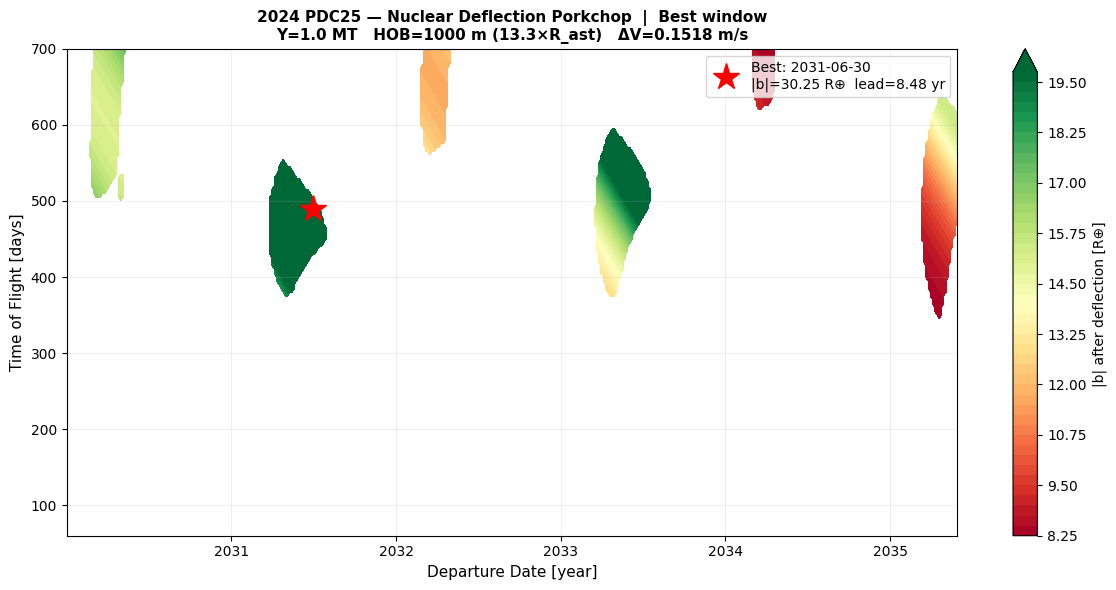

Saved bplane_best_nuclear.png


In [17]:
# ── Find best deflection dates (NUCLEAR) ──────────────────────
import numpy as np
from astropy.time import Time

# Only consider successful misses (b > b_coll)
success_mask = (success_grid == 1.0) & (bplane_grid < 900)  # exclude 999 sentinel

if not success_mask.any():
    print('No successful deflections found in grid!')
else:
    b_finite = np.copy(bplane_grid)
    b_finite[~success_mask] = np.nan

    flat_indices = np.argsort(b_finite.ravel())[::-1]
    flat_indices = flat_indices[np.isfinite(b_finite.ravel()[flat_indices])]

    print('='*80)
    print(f'TOP 10 NUCLEAR DEFLECTION WINDOWS')
    print(f'Y={Y_MT} MT  HOB={h_standoff:.0f} m ({h_standoff/R_ast_m:.1f}×R_ast)  '
          f'η={eta_ablation}  ΔV={dv_ast_ms:.4f} m/s')
    print('='*80)
    print(f'  {"Rank":>4}  {"Departure":>12}  {"Arrival":>12}  '
          f'{"TOF(d)":>7}  {"C3":>8}  {"Lead(yr)":>9}  {"b (R⊕)":>9}')
    print('-'*80)

    shown = 0
    for flat_idx in flat_indices:
        if shown >= 10:
            break
        i, j   = np.unravel_index(flat_idx, bplane_grid.shape)
        t_dep  = depart_dates[j]
        tof    = tof_values[i]
        t_arr  = t_dep + tof
        b_Re   = bplane_grid[i, j]
        C3_val = C3_grid[i, j]
        lead   = (mjd_impact - t_arr) / 365.25

        dep_str = Time(t_dep, format='mjd', scale='tdb').iso[:10]
        arr_str = Time(t_arr, format='mjd', scale='tdb').iso[:10]

        print(f'  {shown+1:>4}  {dep_str:>12}  {arr_str:>12}  '
              f'{tof:>7.0f}  {C3_val:>8.2f}  '
              f'{lead:>9.3f}  {b_Re:>9.3f}')
        shown += 1

    print('='*80)

    # ── Pick the single best ──────────────────────────────────
    best_flat = flat_indices[0]
    bi, bj    = np.unravel_index(best_flat, bplane_grid.shape)

    BEST_DEP_MJD = depart_dates[bj]
    BEST_ARR_MJD = depart_dates[bj] + tof_values[bi]
    BEST_TOF     = tof_values[bi]
    BEST_B_Re    = bplane_grid[bi, bj]
    BEST_C3      = C3_grid[bi, bj]
    BEST_LEAD    = (mjd_impact - BEST_ARR_MJD) / 365.25

    best_dep_str = Time(BEST_DEP_MJD, format='mjd', scale='tdb').iso[:10]
    best_arr_str = Time(BEST_ARR_MJD, format='mjd', scale='tdb').iso[:10]

    # ── Disruption check ──────────────────────────────────────
    G_SI      = 6.674e-11
    v_esc_ms  = np.sqrt(2 * G_SI * m_ast / R_ast_m)
    ratio_vesc = dv_ast_ms / v_esc_ms

    print(f'\nOPTIMAL NUCLEAR MISSION:')
    print(f'  Departure  : {best_dep_str}')
    print(f'  Arrival    : {best_arr_str}')
    print(f'  TOF        : {BEST_TOF:.0f} days  ({BEST_TOF/365.25:.2f} yr)')
    print(f'  C3         : {BEST_C3:.2f} km²/s²')
    print(f'  Lead time  : {BEST_LEAD:.3f} yr before impact')
    print(f'  |b|        : {BEST_B_Re:.3f} R⊕  (b_coll={b_coll_Re:.3f} R⊕)')
    print(f'  Margin     : {BEST_B_Re/b_coll_Re:.2f}×  above b_coll')
    print(f'── Nuclear parameters ───────────────────────────────')
    print(f'  Yield      : {Y_MT} MT')
    print(f'  HOB        : {h_standoff:.0f} m  ({h_standoff/R_ast_m:.1f}×R_ast)')
    print(f'  ΔV on ast  : {dv_ast_ms:.4f} m/s')
    print(f'  v_esc      : {v_esc_ms*100:.2f} cm/s')
    print(f'  ΔV/v_esc   : {ratio_vesc:.1f}×  ', end='')
    if ratio_vesc <= 0.1:
        print('← SAFE deflection regime')
    elif ratio_vesc >= 10.0:
        print('← WARNING: disruption likely')
    else:
        print('← intermediate: fragmentation risk')

    # ── Set as CHOSEN for downstream cells ───────────────────
    CHOSEN_DEP_MJD = BEST_DEP_MJD
    CHOSEN_ARR_MJD = BEST_ARR_MJD
    CHOSEN_TOF     = BEST_TOF
    print(f'\n→ CHOSEN_DEP_MJD, CHOSEN_ARR_MJD, CHOSEN_TOF set for downstream cells')

    # ── Plot ──────────────────────────────────────────────────
    def mjd_to_year(mjd):
        return Time(mjd, format='mjd', scale='tdb').decimalyear

    depart_years = np.array([mjd_to_year(m) for m in depart_dates])
    X, Y_mesh   = np.meshgrid(depart_years, tof_values)

    bplane_plot = np.clip(bplane_grid, 0, 20)

    fig, ax = plt.subplots(figsize=(12, 6))
    cf = ax.contourf(X, Y_mesh, bplane_plot, levels=50, cmap='RdYlGn', extend='max')
    plt.colorbar(cf, ax=ax, label='|b| after deflection [R⊕]')

    cs = ax.contour(X, Y_mesh, bplane_grid,
                    levels=[b_coll_Re], colors='white', linewidths=2.0)
    ax.clabel(cs, fmt=f'b_coll={b_coll_Re:.2f} R⊕', fontsize=9, colors='white')


    # Mark best
    ax.plot(depart_years[bj], BEST_TOF, 'r*', ms=20, zorder=10,
            label=f'Best: {best_dep_str}\n'
                  f'|b|={BEST_B_Re:.2f} R⊕  lead={BEST_LEAD:.2f} yr')

    ax.set_xlabel('Departure Date [year]', fontsize=11)
    ax.set_ylabel('Time of Flight [days]', fontsize=11)
    ax.set_title(
        f'2024 PDC25 — Nuclear Deflection Porkchop  |  Best window\n'
        f'Y={Y_MT} MT   HOB={h_standoff:.0f} m ({h_standoff/R_ast_m:.1f}×R_ast)   '
        f'ΔV={dv_ast_ms:.4f} m/s',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig('./bplane_best_nuclear.png', dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved bplane_best_nuclear.png')

## Cell 7 — Porkchop Plot

Best departure : 2031-06-30
Best arrival   : 2032-11-01
TOF            : 490 days
|b|            : 30.253 R⊕  (b_coll=1.706 R⊕)
dv_total       : 12.347 km/s
C3             : 24.23 km²/s²
Lead time      : 8.478 yr before impact


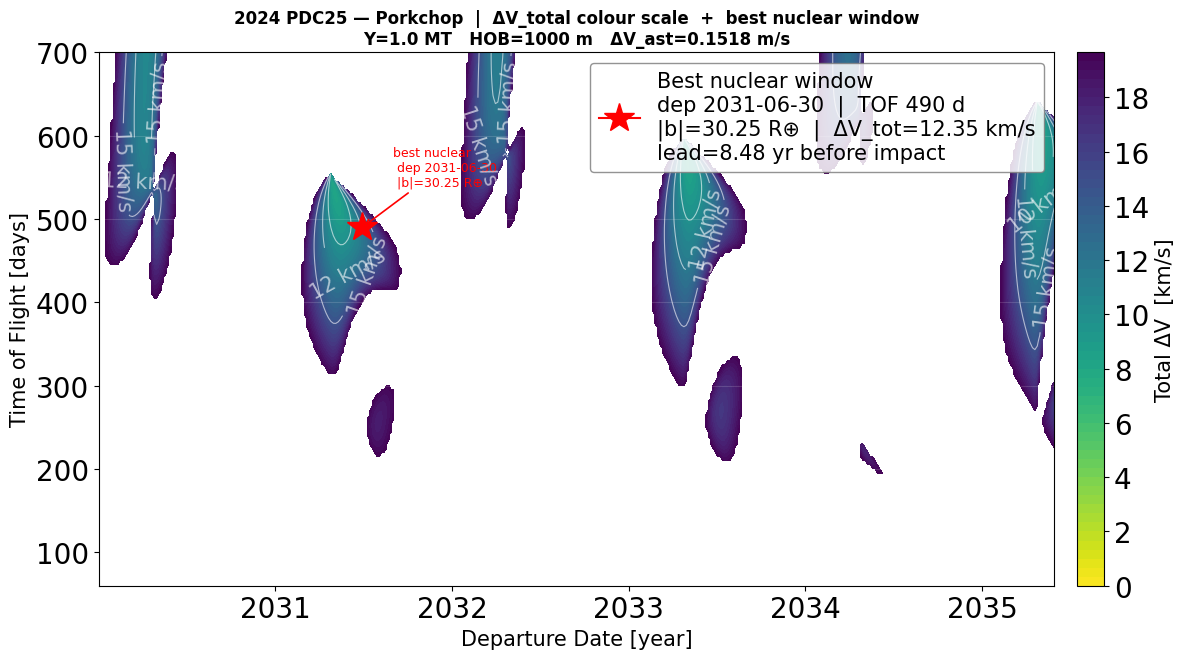

Saved porkchop_dvtotal_nuclear_best.png


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
from astropy.time import Time

# ── Load porkchop data ────────────────────────────────────────
with open('./data/porkchop_2.json', 'r') as f:
    pc = json.load(f)

depart_dates  = np.array(pc['depart_dates'])
tof_values    = np.array(pc['tof_values'])
C3_grid       = np.array(pc['C3_grid'])
vrel_grid     = np.array(pc['vrel_grid'])
dv_total_grid = np.array(pc['dv_tot_grid'])
mjd_impact    = pc['mjd_impact']

# ── Load nuclear b-plane sweep results ───────────────────────
with open('./data/bplane_sweep_nuclear.json', 'r') as f:
    bp = json.load(f)

bplane_grid  = np.array(bp['bplane_grid'])
success_grid = np.array(bp['success_grid'])
b_coll_Re    = bp['b_coll_Re']
Y_MT         = bp['Y_MT']
h_standoff   = bp['h_standoff_m']
dv_ast_ms    = bp['dv_ast_ms']

# ── Find best nuclear window (max |b| among successful misses) ─
success_mask = (success_grid == 1.0) & (bplane_grid < 900)
b_finite = np.full_like(bplane_grid, np.nan)
b_finite[success_mask] = bplane_grid[success_mask]

flat_indices = np.argsort(b_finite.ravel())[::-1]
flat_indices = flat_indices[np.isfinite(b_finite.ravel()[flat_indices])]

best_flat = flat_indices[0]
bi, bj    = np.unravel_index(best_flat, bplane_grid.shape)

BEST_DEP_MJD = depart_dates[bj]
BEST_TOF     = tof_values[bi]
BEST_ARR_MJD = BEST_DEP_MJD + BEST_TOF
BEST_B_Re    = bplane_grid[bi, bj]
BEST_C3      = C3_grid[bi, bj]
BEST_DV_TOT  = dv_total_grid[bi, bj]
BEST_VREL    = vrel_grid[bi, bj]
BEST_LEAD    = (mjd_impact - BEST_ARR_MJD) / 365.25

best_dep_str = Time(BEST_DEP_MJD, format='mjd', scale='tdb').iso[:10]
best_arr_str = Time(BEST_ARR_MJD, format='mjd', scale='tdb').iso[:10]

print(f'Best departure : {best_dep_str}')
print(f'Best arrival   : {best_arr_str}')
print(f'TOF            : {BEST_TOF:.0f} days')
print(f'|b|            : {BEST_B_Re:.3f} R⊕  (b_coll={b_coll_Re:.3f} R⊕)')
print(f'dv_total       : {BEST_DV_TOT:.3f} km/s')
print(f'C3             : {BEST_C3:.2f} km²/s²')
print(f'Lead time      : {BEST_LEAD:.3f} yr before impact')

# ── Helpers ───────────────────────────────────────────────────
def mjd_to_year(mjd):
    return Time(mjd, format='mjd', scale='tdb').decimalyear

depart_years = np.array([mjd_to_year(m) for m in depart_dates])
X, Y_mesh   = np.meshgrid(depart_years, tof_values)

# ── Prepare dv_total colour field ────────────────────────────
DV_MAX = 20.0   # anything above this → NaN, not plotted

valid_mask = (
    np.isfinite(C3_grid)        &
    np.isfinite(vrel_grid)      &
    np.isfinite(dv_total_grid)  &
    (dv_total_grid <= DV_MAX)
)

dv_plot = np.where(valid_mask, dv_total_grid, np.nan)

# ── Plot ──────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 20})   # raises all default text by 2

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')

# dv_total colour scale — no extend, NaN regions stay blank
levels = np.linspace(0, DV_MAX, 60)
cf = ax.contourf(X, Y_mesh, dv_plot,
                 levels=levels, cmap='viridis_r')
cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('Total ΔV  [km/s]', fontsize=15)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

# dv_total contour lines
cs_dv = ax.contour(X, Y_mesh, dv_plot,
                   levels=[3, 4, 5, 6, 7, 8, 10, 12, 15, 20],
                   colors='white', linewidths=0.8, alpha=0.6)
ax.clabel(cs_dv, fmt='%g km/s', fontsize=15, colors='white')

# C3 = 0 boundary
cs_c3 = ax.contour(X, Y_mesh,
                   np.where(np.isfinite(C3_grid), C3_grid, np.nan),
                   levels=[0.0], colors='cyan', linewidths=1.5, linestyles='--')
ax.clabel(cs_c3, fmt='C₃=0', fontsize=9, colors='cyan')

# Nuclear success boundary — b_coll contour
bplane_plot = np.where(success_mask, bplane_grid, np.nan)
cs_b = ax.contour(X, Y_mesh, bplane_plot,
                  levels=[b_coll_Re], colors='lime', linewidths=2.0)
ax.clabel(cs_b, fmt=f'b_coll={b_coll_Re:.2f} R⊕', fontsize=9, colors='lime')

# Best nuclear window star
ax.plot(depart_years[bj], BEST_TOF,
        marker='*', color='red', markersize=22, zorder=10,
        label=(f'Best nuclear window\n'
               f'dep {best_dep_str}  |  TOF {BEST_TOF:.0f} d\n'
               f'|b|={BEST_B_Re:.2f} R⊕  |  ΔV_tot={BEST_DV_TOT:.2f} km/s\n'
               f'lead={BEST_LEAD:.2f} yr before impact'))

ax.annotate(
    f' best nuclear\n  dep {best_dep_str}\n  |b|={BEST_B_Re:.2f} R⊕',
    xy=(depart_years[bj], BEST_TOF),
    xytext=(depart_years[bj] + 0.15, BEST_TOF + 50),
    fontsize=9, color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.2)
)

ax.set_xlabel('Departure Date [year]', fontsize=15)
ax.set_ylabel('Time of Flight [days]', fontsize=15)
ax.set_title(
    f'2024 PDC25 — Porkchop  |  ΔV_total colour scale  +  best nuclear window\n'
    f'Y={Y_MT} MT   HOB={h_standoff:.0f} m   ΔV_ast={dv_ast_ms:.4f} m/s',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=15, loc='upper right', framealpha=0.85, edgecolor='gray')
ax.grid(True, alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('./porkchop_dvtotal_nuclear_best.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved porkchop_dvtotal_nuclear_best.png')

## Cell 8 — Pick Mission Dates & Compute ΔV to Asteroid

In [22]:
# ── You can override with a manually chosen date here ────────
# Default: use best from nuclear b-plane sweep
CHOSEN_DEP_MJD = BEST_DEP_MJD
CHOSEN_ARR_MJD = BEST_ARR_MJD
CHOSEN_TOF     = BEST_TOF

# ── Re-run Lambert for chosen dates ──────────────────────────
r_earth_dep, v_earth_dep = earth_state_at(CHOSEN_DEP_MJD)
r_ast_arr,   v_ast_arr   = asteroid_state_at(CHOSEN_ARR_MJD)

V1_sc, V2_sc = lambert(r_earth_dep, r_ast_arr, CHOSEN_TOF)

# Launch ΔV
dv_launch_vec = V1_sc - v_earth_dep
dv_launch_kms = np.linalg.norm(dv_launch_vec) * AU_KM / DAY_S
C3_chosen     = dv_launch_kms**2

# Relative velocity at asteroid (for reporting — not used for ΔV transfer)
dv_rel_vec = V2_sc - v_ast_arr
v_rel_kms  = np.linalg.norm(dv_rel_vec) * AU_KM / DAY_S

# ── Asteroid physical properties ─────────────────────────────
rho_ast  = 1900.0      # kg/m³
R_ast_m  = 75.0        # m
m_ast    = (4/3) * np.pi * R_ast_m**3 * rho_ast

print(f'Asteroid mass = {m_ast:.4e} kg')

# ── Nuclear standoff parameters ───────────────────────────────
Y_MT         = 1.0      # yield [megatons]
h_standoff   = 1000.0   # standoff height above surface [m]
eta_ablation = 0.1      # X-ray → momentum coupling efficiency
v_ej_ms      = 2000.0   # ablation ejecta velocity [m/s]

# ── Derived nuclear quantities ────────────────────────────────
J_per_MT   = 4.184e15
Y_J        = Y_MT * J_per_MT
r_burst_m  = R_ast_m + h_standoff

sin_theta  = R_ast_m / r_burst_m
cos_theta  = np.sqrt(1.0 - sin_theta**2)
f_geo      = 0.5 * (1.0 - cos_theta)

E_dep      = eta_ablation * f_geo * Y_J
dv_ast_ms  = (2.0 * E_dep) / (m_ast * v_ej_ms)
dv_ast_kms = dv_ast_ms / 1000.0
dv_ast_AUday = dv_ast_kms / (AU_KM / DAY_S)

# ΔV vector on asteroid — prograde push (along asteroid velocity)
v_ast_hat      = np.array(v_ast_arr) / np.linalg.norm(v_ast_arr)
dv_ast_vec_AUday = dv_ast_AUday * v_ast_hat

# ── Disruption check ──────────────────────────────────────────
G_SI       = 6.674e-11
v_esc_ms   = np.sqrt(2 * G_SI * m_ast / R_ast_m)
ratio_vesc = dv_ast_ms / v_esc_ms

dep_date  = Time(CHOSEN_DEP_MJD, format='mjd', scale='tdb').iso[:10]
arr_date  = Time(CHOSEN_ARR_MJD, format='mjd', scale='tdb').iso[:10]
lead_days = mjd_impact - CHOSEN_ARR_MJD

print('='*58)
print('NUCLEAR STANDOFF MISSION DESIGN SUMMARY')
print('='*58)
print(f'  Departure date       : {dep_date}')
print(f'  Arrival/intercept    : {arr_date}')
print(f'  Time of flight       : {CHOSEN_TOF:.0f} days  ({CHOSEN_TOF/365.25:.2f} yr)')
print(f'  C3 (launch energy)   : {C3_chosen:.2f} km²/s²')
print(f'  v_rel at intercept   : {v_rel_kms:.2f} km/s')
print(f'  Lead time            : {lead_days:.0f} days  ({lead_days/365.25:.2f} yr)')
print('-'*58)
print(f'  Asteroid radius      : {R_ast_m:.1f} m')
print(f'  Asteroid mass        : {m_ast:.4e} kg')
print('-'*58)
print(f'  Yield                : {Y_MT} MT  =  {Y_J:.3e} J')
print(f'  Standoff height      : {h_standoff:.0f} m  ({h_standoff/R_ast_m:.1f}×R_ast)')
print(f'  Burst radius         : {r_burst_m:.1f} m from centre')
print(f'  f_geo                : {f_geo:.4f}  ({100*f_geo:.2f}% fluence intercepted)')
print(f'  η_ablation           : {eta_ablation}')
print(f'  v_ejecta             : {v_ej_ms:.0f} m/s')
print(f'  E deposited          : {E_dep:.3e} J')
print('-'*58)
print(f'  ΔV on asteroid       : {dv_ast_ms:.5f} m/s  ({dv_ast_kms:.6f} km/s)')
print(f'  v_esc (asteroid)     : {v_esc_ms*100:.2f} cm/s')
print(f'  ΔV / v_esc           : {ratio_vesc:.1f}×  ', end='')
if ratio_vesc <= 0.1:
    print('← SAFE deflection regime')
elif ratio_vesc >= 10.0:
    print('← WARNING: disruption likely')
else:
    print('← intermediate: fragmentation risk')
print('='*58)

Asteroid mass = 3.3576e+09 kg
NUCLEAR STANDOFF MISSION DESIGN SUMMARY
  Departure date       : 2031-06-30
  Arrival/intercept    : 2032-11-01
  Time of flight       : 490 days  (1.34 yr)
  C3 (launch energy)   : 24.23 km²/s²
  v_rel at intercept   : 7.43 km/s
  Lead time            : 3097 days  (8.48 yr)
----------------------------------------------------------
  Asteroid radius      : 75.0 m
  Asteroid mass        : 3.3576e+09 kg
----------------------------------------------------------
  Yield                : 1.0 MT  =  4.184e+15 J
  Standoff height      : 1000 m  (13.3×R_ast)
  Burst radius         : 1075.0 m from centre
  f_geo                : 0.0012  (0.12% fluence intercepted)
  η_ablation           : 0.1
  v_ejecta             : 2000 m/s
  E deposited          : 5.098e+11 J
----------------------------------------------------------
  ΔV on asteroid       : 0.15182 m/s  (0.000152 km/s)
  v_esc (asteroid)     : 7.73 cm/s
  ΔV / v_esc           : 2.0×  ← intermediate: fragmenta

## Cell 9 — B-Plane: Nominal Impact

Get asteroid and Earth states at impact time using GRSS interpolation + SPICE.

In [23]:
# In notebook — load pre-computed nominal b-plane
with open('./data/nominal_bplane.json') as f:
    bp_data = json.load(f)

nom     = bp_data['nominal']
cloud   = bp_data['cloud']

AU_KM       = 149597870.7
R_e_km      = 6371.0
MU_EARTH_KMS = 3.986004418e5

U0_kms    = nom['vInf'] * AU_KM / DAY_S
b0_km     = nom['bMag'] * AU_KM
b_coll_km = R_e_km * np.sqrt(1 + 2*MU_EARTH_KMS / (R_e_km * U0_kms**2))
b_coll_Re = b_coll_km / R_e_km
xi0_Re    = nom['xi']   * AU_KM / R_e_km
zeta0_Re  = nom['zeta'] * AU_KM / R_e_km

# 1000-clone uncertainty cloud
xi_cloud   = np.array([c['xi']   for c in cloud]) * AU_KM / R_e_km
zeta_cloud = np.array([c['zeta'] for c in cloud]) * AU_KM / R_e_km

print(f'U∞     = {U0_kms:.4f} km/s')
print(f'|b|    = {b0_km:.4f} km  ({b0_km/R_e_km:.6f} R⊕)')
print(f'b_coll = {b_coll_km:.2f} km  ({b_coll_Re:.4f} R⊕)')
print(f'ξ      = {xi0_Re:+.6f} R⊕')
print(f'ζ      = {zeta0_Re:+.6f} R⊕')
print(f'Cloud  : {len(xi_cloud)} clones')

U∞     = 8.0936 km/s
|b|    = 4129.1332 km  (0.648114 R⊕)
b_coll = 10868.47 km  (1.7059 R⊕)
ξ      = -0.041982 R⊕
ζ      = +0.646753 R⊕
Cloud  : 1000 clones


## Cell 10 — Deflected B-Plane

Apply ΔV to asteroid at intercept, re-propagate using GRSS, get new b-plane.

In [26]:
from grss import prop, utils
import json
import numpy as np
from astropy.time import Time

# ── Load nominal b-plane ──────────────────────────────────────
with open('./data/nominal_bplane.json') as f:
    bp_data = json.load(f)

nom   = bp_data['nominal']
cloud = bp_data['cloud']

AU_KM        = 149597870.7
DAY_S        = 86400.0
R_e_km       = 6371.0
MU_EARTH_KMS = 3.986004418e5

U0_kms    = nom['vInf'] * AU_KM / DAY_S
b0_km     = nom['bMag'] * AU_KM
b_coll_km = R_e_km * np.sqrt(1 + 2*MU_EARTH_KMS / (R_e_km * U0_kms**2))
b_coll_Re = b_coll_km / R_e_km
xi0_Re    = nom['xi']   * AU_KM / R_e_km
zeta0_Re  = nom['zeta'] * AU_KM / R_e_km
mjd_impact = nom['t_ca']

print('NOMINAL IMPACT B-PLANE:')
print(f'  U∞     = {U0_kms:.4f} km/s')
print(f'  ξ      = {xi0_Re:+.6f} R⊕')
print(f'  ζ      = {zeta0_Re:+.6f} R⊕')
print(f'  |b|    = {b0_km:.4f} km  ({b0_km/R_e_km:.6f} R⊕)')
print(f'  b_coll = {b_coll_km:.2f} km  ({b_coll_Re:.4f} R⊕)')

# ── Get asteroid state at intercept ───────────────────────────
r_ast_int, v_ast_int = asteroid_state_at(CHOSEN_ARR_MJD)

# ── Nuclear ΔV — prograde push along asteroid velocity ────────
# dv_ast_vec_AUday already computed in mission design cell:
#   v_ast_hat        = v_ast_arr / |v_ast_arr|
#   dv_ast_vec_AUday = dv_ast_AUday * v_ast_hat
v_ast_deflected = np.array(v_ast_int) + dv_ast_vec_AUday

print(f'\nNuclear ΔV applied:')
print(f'  |ΔV|  = {dv_ast_ms:.5f} m/s  ({dv_ast_kms:.6f} km/s)')
print(f'  Y     = {Y_MT} MT   HOB = {h_standoff:.0f} m   η = {eta_ablation}')
print(f'  Direction: prograde (along asteroid velocity vector)')

# ── Convert deflected Cartesian → cometary for GRSS ──────────
cart_defl     = list(r_ast_int) + list(v_ast_deflected)
cometary_defl = libgrss.cartesian_to_cometary(CHOSEN_ARR_MJD, cart_defl)

defl_sol = {
    't' : CHOSEN_ARR_MJD,
    'e' : cometary_defl[0],
    'q' : cometary_defl[1],
    'tp': cometary_defl[2],
    'om': cometary_defl[3],
    'w' : cometary_defl[4],
    'i' : cometary_defl[5],
    'a2': nongrav_info['a2'],   # keep Yarkovsky
}

# ── Nongrav parameters ────────────────────────────────────────
ng_defl = prop.NongravParameters()
ng_defl.a1    = nongrav_info['a1'];  ng_defl.a1Est = False
ng_defl.a2    = nongrav_info['a2'];  ng_defl.a2Est = True
ng_defl.a3    = nongrav_info['a3'];  ng_defl.a3Est = False
ng_defl.alpha = nongrav_info['alpha']
ng_defl.k     = nongrav_info['k']
ng_defl.m     = nongrav_info['m']
ng_defl.n     = nongrav_info['n']
ng_defl.r0_au = nongrav_info['r0_au']

# ── Propagate deflected orbit ─────────────────────────────────
mjd_end_defl = nom['t_ca'] + 30000

ref_sim_defl = prop.PropSimulation(
    name='2024PDC25_nuclear_defl',
    t0=CHOSEN_ARR_MJD,
    defaultSpiceBodies=440,
    DEkernelPath=utils.default_kernel_path
)
ref_sim_defl.set_integration_parameters(mjd_end_defl)

result_defl = prop.parallel_propagate(
    defl_sol, ng_defl, ref_sim_defl,
    [defl_sol],   # single clone
    1,
    reconstruct=True
)

# ── Extract all close approaches, filter Earth only ───────────
all_cas = result_defl[0][0]
print(f'\nAll close approaches found: {len(all_cas)}')
for i, ca in enumerate(all_cas):
    yr = Time(ca.t, format='mjd').decimalyear
    b  = ca.bMag * AU_KM / R_e_km
    print(f'  [{i}] body={ca.centralBody:6s}  year={yr:.4f}  '
          f'|b|={b:.4f} R⊕  impact={ca.impact}')

# ── Helper: worst Earth close approach ────────────────────────
def get_worst_earth_ca(all_cas):
    earth_cas = [ca for ca in all_cas if ca.centralBody == 'Earth']
    if len(earth_cas) == 0:
        return None
    return min(earth_cas, key=lambda ca: ca.bMag)

worst = get_worst_earth_ca(all_cas)

# ── Assessment ────────────────────────────────────────────────
if worst is None:
    print('\n✓ No Earth close approaches — fully deflected!')
    b_d_Re = 999.0
    xi_d_Re = zeta_d_Re = 0.0
else:
    xi_d_Re   = worst.opik.x * AU_KM / R_e_km
    zeta_d_Re = worst.opik.y * AU_KM / R_e_km
    b_d_km    = worst.bMag * AU_KM
    b_d_Re    = b_d_km / R_e_km
    worst_yr  = Time(worst.t, format='mjd').decimalyear

    print('\n' + '='*58)
    print('NUCLEAR DEFLECTION — B-PLANE ASSESSMENT')
    print('='*58)
    print(f'  Yield                : {Y_MT} MT')
    print(f'  HOB                  : {h_standoff:.0f} m  ({h_standoff/R_ast_m:.1f}×R_ast)')
    print(f'  ΔV on asteroid       : {dv_ast_ms:.5f} m/s')
    print(f'  ΔV / v_esc           : {ratio_vesc:.1f}×  ', end='')
    if ratio_vesc <= 0.1:
        print('← SAFE deflection regime')
    elif ratio_vesc >= 10.0:
        print('← WARNING: disruption likely')
    else:
        print('← intermediate: fragmentation risk')
    print('-'*58)
    print(f'  Year of worst CA     : {worst_yr:.4f}')
    print(f'  ξ (deflected)        = {xi_d_Re:+.4f} R⊕')
    print(f'  ζ (deflected)        = {zeta_d_Re:+.4f} R⊕')
    print(f'  |b| deflected        = {b_d_km:.2f} km  ({b_d_Re:.4f} R⊕)')
    print(f'  b_coll               = {b_coll_km:.2f} km  ({b_coll_Re:.4f} R⊕)')
    print('-'*58)
    print(f'  Δξ                   = {xi_d_Re   - xi0_Re:+.4f} R⊕')
    print(f'  Δζ                   = {zeta_d_Re - zeta0_Re:+.4f} R⊕')
    print(f'  Δ|b|                 = {b_d_Re    - b0_km/R_e_km:+.4f} R⊕')
    print('-'*58)
    if b_d_Re > b_coll_Re:
        print(f'  ✓ MISS — deflection SUCCESSFUL')
        print(f'    |b| = {b_d_Re:.2f} R⊕  >  b_coll = {b_coll_Re:.2f} R⊕')
        print(f'    Margin = {b_d_Re/b_coll_Re:.2f}× above b_coll')
    else:
        print(f'  ✗ STILL IMPACTS — |b| = {b_d_Re:.2f} R⊕  <  b_coll = {b_coll_Re:.2f} R⊕')
        print(f'    → Try: increase yield, lower HOB, or choose earlier intercept')
    print('='*58)

NOMINAL IMPACT B-PLANE:
  U∞     = 8.0936 km/s
  ξ      = -0.041982 R⊕
  ζ      = +0.646753 R⊕
  |b|    = 4129.1332 km  (0.648114 R⊕)
  b_coll = 10868.47 km  (1.7059 R⊕)

Nuclear ΔV applied:
  |ΔV|  = 0.15182 m/s  (0.000152 km/s)
  Y     = 1.0 MT   HOB = 1000 m   η = 0.1
  Direction: prograde (along asteroid velocity vector)
Parallel propagation took 00 minute(s) and 0.538764 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.009152 seconds

All close approaches found: 4
  [0] body=Earth   year=2041.3123  |b|=30.2526 R⊕  impact=False
  [1] body=Moon    year=2041.3131  |b|=76.2261 R⊕  impact=False
  [2] body=Earth   year=2100.3084  |b|=169.7360 R⊕  impact=False
  [3] body=Moon    year=2100.3084  |b|=180.0932 R⊕  impact=False

NUCLEAR DEFLECTION — B-PLANE ASSESSMENT
  Yield                : 1.0 MT
  HOB                  : 1000 m  (13.3×R_ast)
  ΔV on asteroid       : 0.15182 m/s
  ΔV / v_esc           : 2.0×  ← intermediate: fragmentation risk
----------------------------------------------------------
  Year of worst CA     : 2041.3123
  ξ (deflected)        = -0.1755 R⊕
  ζ (deflected)        = +30.2520 R⊕
  |b| deflected        = 192739.05 km  (30.2526 R⊕)
  b_coll               = 10868.47 km  (1.7059 R⊕)
----------------------------------------------------------
  Δξ                   = -0.1335 R⊕
  Δζ                   = +29.6053 R⊕
  Δ|b|                 = +29.6044 

## Cell 11 — B-Plane Plot

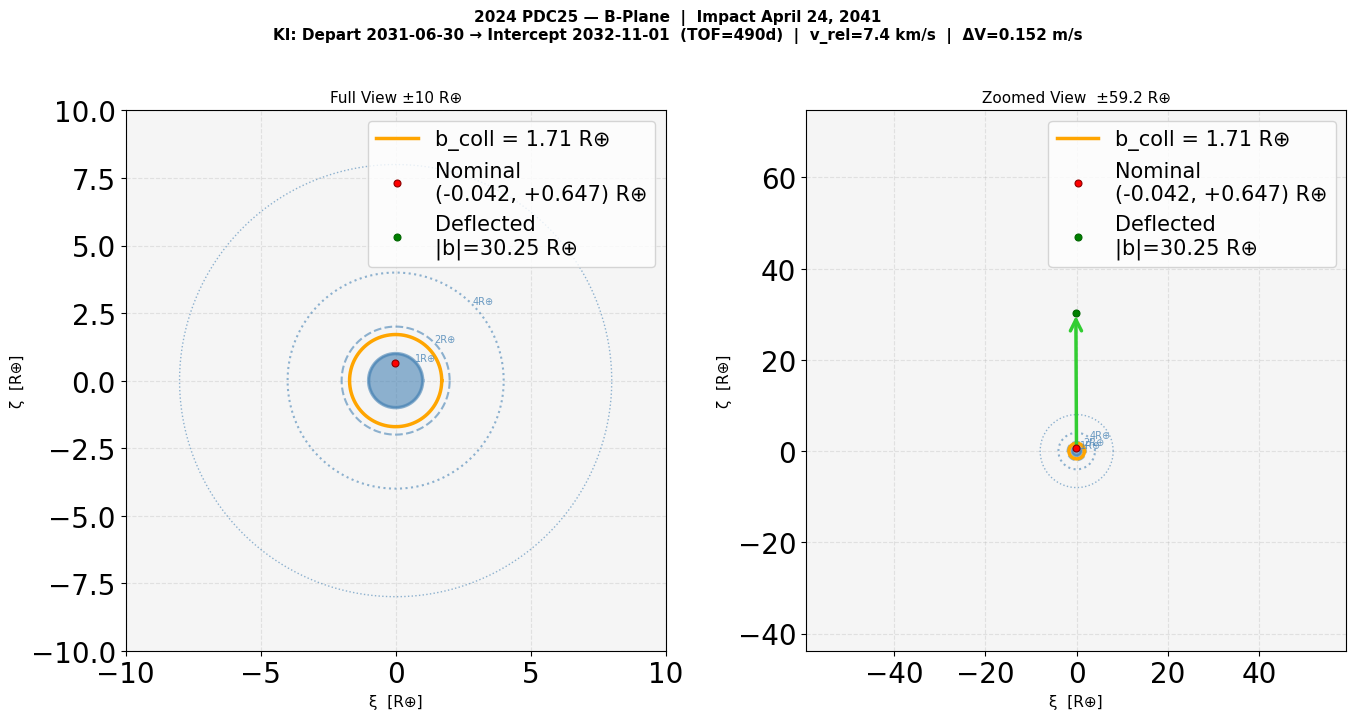

Saved pdr_bplane.png


In [33]:
plt.rcParams.update({'font.size': 20})   # raises all default text by 2


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
theta = np.linspace(0, 2*np.pi, 400)

for ax in axes:
    ax.set_facecolor('#f5f5f5')
    ax.grid(True, alpha=0.3, linestyle='--')

    # Reference circles
    for nr, ls, lw in [(1,'-',2.5),(2,'--',1.5),(4,':',1.5),(8,':',1.0)]:
        ax.plot(nr*np.cos(theta), nr*np.sin(theta),
                ls=ls, lw=lw, color='steelblue', alpha=0.6)
        if nr <= 4:
            ax.text(nr*0.71, nr*0.71, f'{nr}R⊕', fontsize=7,
                    color='steelblue', alpha=0.8)

    # b_coll circle
    ax.plot(b_coll_Re*np.cos(theta), b_coll_Re*np.sin(theta),
            '-', lw=2.5, color='orange',
            label=f'b_coll = {b_coll_Re:.2f} R⊕')

    # Earth
    ax.add_patch(plt.Circle((0,0), 1.0, color='steelblue', alpha=0.6, zorder=4))

    # Nominal impact
    ax.plot(xi0_Re, zeta0_Re, 'r.', ms=10, zorder=9,
            markeredgecolor='darkred', markeredgewidth=0.8,
            label=f'Nominal\n({xi0_Re:+.3f}, {zeta0_Re:+.3f}) R⊕')

    # Deflected
    ax.plot(xi_d_Re, zeta_d_Re, 'g.', ms=10, zorder=10,
            markeredgecolor='darkgreen', markeredgewidth=0.8,
            label=f'Deflected\n|b|={b_d_Re:.2f} R⊕')

    # Arrow
    ax.annotate('',
                xy=(xi_d_Re, zeta_d_Re),
                xytext=(xi0_Re, zeta0_Re),
                arrowprops=dict(arrowstyle='->', color='limegreen',
                                lw=2.5, mutation_scale=20))

    ax.set_aspect('equal')
    ax.set_xlabel('ξ  [R⊕]', fontsize=11)
    ax.set_ylabel('ζ  [R⊕]', fontsize=11)

# Full view
axes[0].set_xlim(-10, 10); axes[0].set_ylim(-10, 10)
axes[0].set_title('Full View ±10 R⊕', fontsize=11)
axes[0].legend(fontsize=15, loc='upper right')

# Zoomed view
pad = max(3.0, abs(xi_d_Re - xi0_Re)*2, abs(zeta_d_Re - zeta0_Re)*2)
cx  = (xi0_Re + xi_d_Re) / 2
cy  = (zeta0_Re + zeta_d_Re) / 2
axes[1].set_xlim(cx-pad, cx+pad); axes[1].set_ylim(cy-pad, cy+pad)
axes[1].set_title(f'Zoomed View  ±{pad:.1f} R⊕', fontsize=11)
axes[1].legend(fontsize=15, loc='upper right')

fig.suptitle(
    f'2024 PDC25 — B-Plane  |  Impact April 24, 2041\n'
    f'KI: Depart {dep_date} → Intercept {arr_date}  '
    f'(TOF={CHOSEN_TOF:.0f}d)  |  '
    f'v_rel={v_rel_kms:.1f} km/s  |  ΔV={dv_ast_ms:.3f} m/s',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('./pdr_bplane.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved pdr_bplane.png')

## Cell 12 — PDR Summary Table

In [30]:
print('='*60)
print('PDR SUMMARY — 2024 PDC25 Nuclear Standoff Deflection')
print('='*60)
print(f'  Impact date          : April 24, 2041')
print(f'  Departure date       : {dep_date}')
print(f'  Intercept date       : {arr_date}')
print(f'  Time of flight       : {CHOSEN_TOF:.0f} d  ({CHOSEN_TOF/365.25:.1f} yr)')
print(f'  Lead time            : {lead_days:.0f} d  ({lead_days/365.25:.1f} yr)')
print('-'*60)
print(f'  C3 (launch energy)   : {C3_chosen:.2f} km²/s²')
print(f'  v_rel at intercept   : {v_rel_kms:.2f} km/s')
print(f'  Yield                : {Y_MT} MT  =  {Y_J:.3e} J')
print(f'  Standoff height      : {h_standoff:.0f} m  ({h_standoff/R_ast_m:.1f}×R_ast)')
print(f'  f_geo                : {f_geo:.4f}  ({100*f_geo:.2f}% fluence intercepted)')
print(f'  η_ablation           : {eta_ablation}')
print(f'  v_ejecta             : {v_ej_ms:.0f} m/s')
print(f'  E deposited          : {E_dep:.3e} J')
print(f'  ΔV to asteroid       : {dv_ast_ms:.5f} m/s')
print(f'  ΔV / v_esc           : {ratio_vesc:.1f}×  ', end='')
if ratio_vesc <= 0.1:
    print('← safe deflection regime')
elif ratio_vesc >= 10.0:
    print('← WARNING: disruption likely')
else:
    print('← intermediate: fragmentation risk')
print('-'*60)
print(f'  U∞                   : {U0_kms:.3f} km/s')
print(f'  b_coll               : {b_coll_km:.1f} km  ({b_coll_Re:.3f} R⊕)')
print(f'  Nominal |b|          : {b0_km:.2f} km  ({b0_km/R_e_km:.5f} R⊕)')
print(f'  Deflected |b|        : {b_d_km:.2f} km  ({b_d_Re:.4f} R⊕)')
print(f'  Margin               : {b_d_Re/b_coll_Re:.2f}× above b_coll')
outcome = '✓ MISS' if b_d_Re > b_coll_Re else '✗ STILL IMPACTING'
print(f'  Outcome              : {outcome}')
print('='*60)

PDR SUMMARY — 2024 PDC25 Nuclear Standoff Deflection
  Impact date          : April 24, 2041
  Departure date       : 2031-06-30
  Intercept date       : 2032-11-01
  Time of flight       : 490 d  (1.3 yr)
  Lead time            : 3097 d  (8.5 yr)
------------------------------------------------------------
  C3 (launch energy)   : 24.23 km²/s²
  v_rel at intercept   : 7.43 km/s
  Yield                : 1.0 MT  =  4.184e+15 J
  Standoff height      : 1000 m  (13.3×R_ast)
  f_geo                : 0.0012  (0.12% fluence intercepted)
  η_ablation           : 0.1
  v_ejecta             : 2000 m/s
  E deposited          : 5.098e+11 J
  ΔV to asteroid       : 0.15182 m/s
  ΔV / v_esc           : 2.0×  ← intermediate: fragmentation risk
------------------------------------------------------------
  U∞                   : 8.094 km/s
  b_coll               : 10868.5 km  (1.706 R⊕)
  Nominal |b|          : 4129.13 km  (0.64811 R⊕)
  Deflected |b|        : 192739.05 km  (30.2526 R⊕)
  Margin     